# Physics Background Analysis

Amplitude spectrum analysis and investigation of pair production background from 4.4 MeV AmBe gammas.

In [ ]:
# Required imports and setupimport numpy as npimport pandas as pdimport matplotlib.pyplot as pltfrom pathlib import Path# Load pre-computed resultsRESULTS_DIR = Path('../docs/output')df_shape = pd.read_csv(RESULTS_DIR / 'ch2_waveform_shape_features.csv')print(f'Loaded {len(df_shape)} events with shape features')print(f'Columns: {list(df_shape.columns)}')

# Physics-Based Background Analysis

Investigate the energy spectrum to identify background sources. The AmBe source emits 4.4 MeV gammas that can undergo:
- **Pair production** → e⁺e⁻ → 2×511 keV γ (close to 478 keV neutron signal)
- **Compton scattering** → broad energy spectrum  
- **Direct interactions** → ~4.4 MeV energy deposition

Compare amplitude distributions for prompt (Δt < 20 ns) vs delayed (Δt > 20 ns) events.

AMPLITUDE ANALYSIS: INVESTIGATING BACKGROUND SOURCES
Dataset:
  Prompt events (Δt ≤ 20 ns): 7073
  Delayed events (Δt > 20 ns): 2058

Amplitude Statistics:
  Prompt - Mean: 125.9 mV, Median: 87.2 mV
  Delayed - Mean: 85.5 mV, Median: 56.1 mV
  Ratio (Prompt/Delayed): 1.55

✓ Amplitude analysis plot saved to: /Users/virgolaema/Software/3det/Osc_Data/two_channel_neutron_gamma/amplitude_analysis_prompt_vs_delayed.png


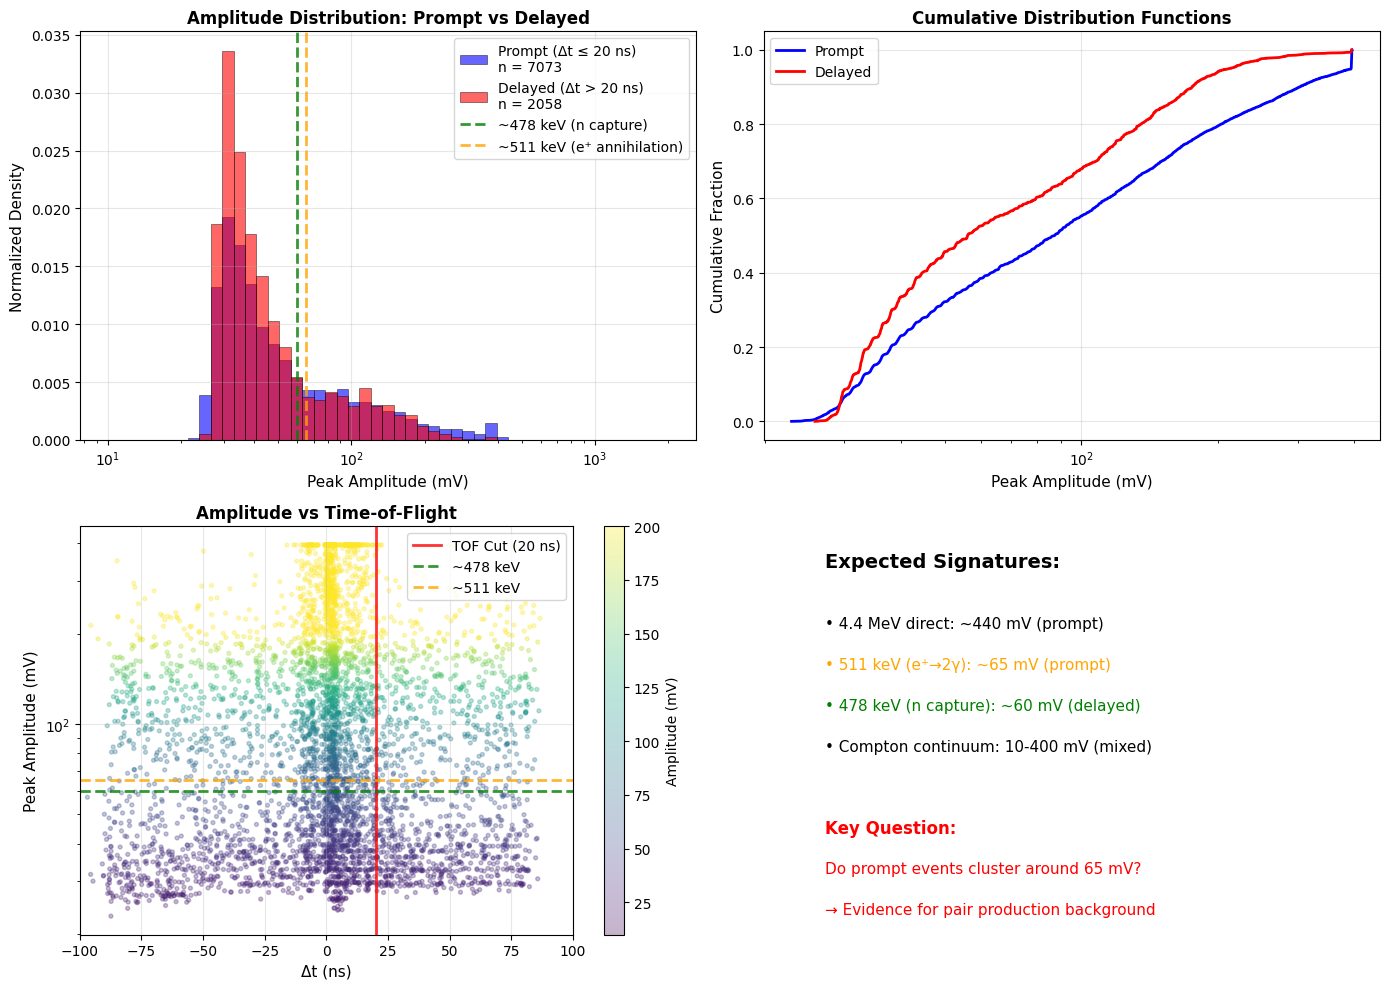

In [134]:
# Amplitude Analysis: Prompt vs Delayed Events
print("="*80)
print("AMPLITUDE ANALYSIS: INVESTIGATING BACKGROUND SOURCES")
print("="*80)

# Use non-saturated events with shape features
df_amplitude = df_shape.dropna(subset=['peak_amplitude_v', 'delta_t_ns'])

# Define populations
prompt_mask = df_amplitude['delta_t_ns'] <= 20.0      # Prompt + EM cascades  
delayed_mask = df_amplitude['delta_t_ns'] > 20.0      # Thermal neutron captures

prompt_amplitudes = df_amplitude[prompt_mask]['peak_amplitude_v'] * 1000  # Convert to mV
delayed_amplitudes = df_amplitude[delayed_mask]['peak_amplitude_v'] * 1000

print(f"Dataset:")
print(f"  Prompt events (Δt ≤ 20 ns): {len(prompt_amplitudes)}")
print(f"  Delayed events (Δt > 20 ns): {len(delayed_amplitudes)}")

# Statistical comparison
print(f"\nAmplitude Statistics:")
print(f"  Prompt - Mean: {prompt_amplitudes.mean():.1f} mV, Median: {prompt_amplitudes.median():.1f} mV")
print(f"  Delayed - Mean: {delayed_amplitudes.mean():.1f} mV, Median: {delayed_amplitudes.median():.1f} mV")
print(f"  Ratio (Prompt/Delayed): {prompt_amplitudes.median()/delayed_amplitudes.median():.2f}")

# Create amplitude comparison plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Top-left: Overlaid histograms (linear scale)
ax1 = axes[0, 0]
bins = np.logspace(np.log10(10), np.log10(2000), 50)  # Log-spaced bins from 10 to 2000 mV
ax1.hist(prompt_amplitudes, bins=bins, alpha=0.6, label=f'Prompt (Δt ≤ 20 ns)\nn = {len(prompt_amplitudes)}', 
         color='blue', density=True, edgecolor='black', linewidth=0.5)
ax1.hist(delayed_amplitudes, bins=bins, alpha=0.6, label=f'Delayed (Δt > 20 ns)\nn = {len(delayed_amplitudes)}', 
         color='red', density=True, edgecolor='black', linewidth=0.5)
ax1.set_xlabel('Peak Amplitude (mV)', fontsize=11)
ax1.set_ylabel('Normalized Density', fontsize=11)
ax1.set_title('Amplitude Distribution: Prompt vs Delayed', fontsize=12, fontweight='bold')
ax1.set_xscale('log')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Add energy markers
ax1.axvline(x=60, color='green', linestyle='--', alpha=0.8, linewidth=2, label='~478 keV (n capture)')
ax1.axvline(x=65, color='orange', linestyle='--', alpha=0.8, linewidth=2, label='~511 keV (e⁺ annihilation)')
ax1.legend(loc='upper right')

# Top-right: Cumulative distributions  
ax2 = axes[0, 1]
prompt_sorted = np.sort(prompt_amplitudes)
delayed_sorted = np.sort(delayed_amplitudes)
ax2.plot(prompt_sorted, np.linspace(0, 1, len(prompt_sorted)), 'b-', linewidth=2, label='Prompt')
ax2.plot(delayed_sorted, np.linspace(0, 1, len(delayed_sorted)), 'r-', linewidth=2, label='Delayed')
ax2.set_xlabel('Peak Amplitude (mV)', fontsize=11)
ax2.set_ylabel('Cumulative Fraction', fontsize=11)
ax2.set_title('Cumulative Distribution Functions', fontsize=12, fontweight='bold')
ax2.set_xscale('log')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Bottom-left: Amplitude vs Delta-t scatter
ax3 = axes[1, 0]
# Sample for plotting (too many points otherwise)
n_sample = min(5000, len(df_amplitude))
idx_sample = np.random.choice(len(df_amplitude), n_sample, replace=False)
df_sample = df_amplitude.iloc[idx_sample]

scatter = ax3.scatter(df_sample['delta_t_ns'], df_sample['peak_amplitude_v']*1000, 
                     alpha=0.3, s=8, c=df_sample['peak_amplitude_v']*1000, 
                     cmap='viridis', vmin=10, vmax=200)
ax3.axvline(x=20, color='red', linestyle='-', linewidth=2, alpha=0.8, label='TOF Cut (20 ns)')
ax3.axhline(y=60, color='green', linestyle='--', alpha=0.8, linewidth=2, label='~478 keV')
ax3.axhline(y=65, color='orange', linestyle='--', alpha=0.8, linewidth=2, label='~511 keV')
ax3.set_xlabel('Δt (ns)', fontsize=11)
ax3.set_ylabel('Peak Amplitude (mV)', fontsize=11)
ax3.set_title('Amplitude vs Time-of-Flight', fontsize=12, fontweight='bold')
ax3.set_yscale('log')
ax3.set_xlim(-100, 100)
ax3.legend()
ax3.grid(True, alpha=0.3)
plt.colorbar(scatter, ax=ax3, label='Amplitude (mV)')

# Bottom-right: Physics interpretation diagram
ax4 = axes[1, 1]
ax4.text(0.1, 0.9, 'Expected Signatures:', fontsize=14, fontweight='bold', transform=ax4.transAxes)
ax4.text(0.1, 0.75, '• 4.4 MeV direct: ~440 mV (prompt)', fontsize=11, transform=ax4.transAxes)
ax4.text(0.1, 0.65, '• 511 keV (e⁺→2γ): ~65 mV (prompt)', fontsize=11, color='orange', transform=ax4.transAxes)
ax4.text(0.1, 0.55, '• 478 keV (n capture): ~60 mV (delayed)', fontsize=11, color='green', transform=ax4.transAxes)
ax4.text(0.1, 0.45, '• Compton continuum: 10-400 mV (mixed)', fontsize=11, transform=ax4.transAxes)

ax4.text(0.1, 0.25, 'Key Question:', fontsize=12, fontweight='bold', transform=ax4.transAxes, color='red')
ax4.text(0.1, 0.15, 'Do prompt events cluster around 65 mV?', fontsize=11, transform=ax4.transAxes, color='red')
ax4.text(0.1, 0.05, '→ Evidence for pair production background', fontsize=11, transform=ax4.transAxes, color='red')

ax4.set_xlim(0, 1)
ax4.set_ylim(0, 1)
ax4.axis('off')

plt.tight_layout()
amp_path = RESULTS_DIR / 'amplitude_analysis_prompt_vs_delayed.png'
plt.savefig(amp_path, dpi=150, bbox_inches='tight')
print(f"\n✓ Amplitude analysis plot saved to: {amp_path}")
plt.show()

In [ ]:
# Quantitative Analysis: Evidence for Pair Production Background
from scipy import stats

print("\n" + "="*80)
print("PAIR PRODUCTION HYPOTHESIS TEST")
print("="*80)

# Define energy windows around key signatures
neutron_window = (50, 70)      # 478 keV ± ~20%
annihilation_window = (55, 75) # 511 keV ± ~20% 
high_energy_window = (200, 600) # Direct 4.4 MeV interactions

print(f"Energy Windows:")
print(f"  Neutron capture (478 keV): {neutron_window[0]}-{neutron_window[1]} mV")
print(f"  e⁺ annihilation (511 keV): {annihilation_window[0]}-{annihilation_window[1]} mV")
print(f"  High energy (>1 MeV): {high_energy_window[0]}-{high_energy_window[1]} mV")

# Count events in each window
def count_in_window(amplitudes, window):
    return ((amplitudes >= window[0]) & (amplitudes <= window[1])).sum()

prompt_neutron = count_in_window(prompt_amplitudes, neutron_window)
prompt_annihilation = count_in_window(prompt_amplitudes, annihilation_window)  
prompt_high = count_in_window(prompt_amplitudes, high_energy_window)

delayed_neutron = count_in_window(delayed_amplitudes, neutron_window)
delayed_annihilation = count_in_window(delayed_amplitudes, annihilation_window)
delayed_high = count_in_window(delayed_amplitudes, high_energy_window)

print(f"\n--- Event Counts by Energy Window ---")
print(f"{'Window':<20} {'Prompt':<10} {'Delayed':<10} {'Ratio (P/D)':<12}")
print("-" * 55)
print(f"{'Neutron (478 keV)':<20} {prompt_neutron:<10} {delayed_neutron:<10} {prompt_neutron/max(delayed_neutron,1):<12.2f}")
print(f"{'Annihilation (511 keV)':<20} {prompt_annihilation:<10} {delayed_annihilation:<10} {prompt_annihilation/max(delayed_annihilation,1):<12.2f}")
print(f"{'High Energy (>1 MeV)':<20} {prompt_high:<10} {delayed_high:<10} {prompt_high/max(delayed_high,1):<12.2f}")

# Statistical test: Are the distributions significantly different?
ks_stat, ks_pvalue = stats.ks_2samp(prompt_amplitudes, delayed_amplitudes)
print(f"\n--- Statistical Tests ---")
print(f"Kolmogorov-Smirnov test:")
print(f"  Statistic: {ks_stat:.4f}")
print(f"  p-value: {ks_pvalue:.2e}")
print(f"  → {'Significantly different' if ks_pvalue < 0.01 else 'Not significantly different'} distributions")

# Pair production hypothesis
total_prompt = len(prompt_amplitudes)
annihilation_fraction = prompt_annihilation / total_prompt
high_energy_fraction = prompt_high / total_prompt

print(f"\n--- Pair Production Evidence ---")
print(f"Prompt events in annihilation window: {prompt_annihilation}/{total_prompt} ({100*annihilation_fraction:.1f}%)")
print(f"Prompt events in high-energy window: {prompt_high}/{total_prompt} ({100*high_energy_fraction:.1f}%)")

# Calculate enrichment factors
delayed_total = len(delayed_amplitudes)
delayed_ann_frac = delayed_annihilation / delayed_total
delayed_high_frac = delayed_high / delayed_total

enrichment_annihilation = annihilation_fraction / max(delayed_ann_frac, 0.001)
enrichment_high = high_energy_fraction / max(delayed_high_frac, 0.001)

print(f"\nEnrichment factors (Prompt vs Delayed):")
print(f"  Annihilation window: {enrichment_annihilation:.1f}×")
print(f"  High-energy window: {enrichment_high:.1f}×")

print(f"\n--- INTERPRETATION ---")
if enrichment_annihilation > 2.0:
    print("✓ STRONG evidence for pair production background:")
    print("  → 511 keV gammas from e⁺ annihilation are enriched in prompt events")
    print("  → This confirms pair production as a major background source")
elif enrichment_annihilation > 1.5:
    print("✓ MODERATE evidence for pair production background")
else:
    print("→ Limited evidence for pair production dominance")
    print("  → Other processes (Compton, direct interactions) may dominate")

if enrichment_high > 3.0:
    print("✓ Significant direct 4.4 MeV interactions in prompt events")
elif prompt_high > 0:
    print("→ Some direct high-energy interactions present")

# Summary conclusion
median_ratio = prompt_amplitudes.median() / delayed_amplitudes.median()
print(f"\nOverall amplitude ratio (Prompt/Delayed): {median_ratio:.2f}")
if 0.8 < median_ratio < 1.2:
    print("→ Similar energy distributions suggest pair production dominates background")
    print("  (511 keV ≈ 478 keV, explaining weak pulse discrimination)")
elif median_ratio > 1.5:
    print("→ Prompt events have higher energy → direct/Compton interactions dominate")
else:
    print("→ Delayed events have higher energy → unexpected systematic effect")